# 📊 COVID-19 Global Data Analysis

Exploratory data analysis of COVID-19 trends across 248 countries and 6 continents using the **Our World in Data** dataset.

---

## 📁 Dataset
- **File:** `covid_data.csv`
- **Rows:** 262,423 | **Columns:** 67
- **Date range:** January 2020 – March 2023

---

## 🗂️ Notebook Structure

| Part | Description |
|------|-------------|
| 1 | Imports & styling setup |
| 2 | Load CSV data |
| 3 | Explore shape, columns, missing values, basic stats |
| 4 | Clean data — drop high-missing columns, forward/backward fill |
| 5 | Filter & summarize — global stats, top countries, continent breakdown, monthly trends |
| 6 | Visualizations (8 charts) |
| 7 | Key findings & summary table |

---

## 📉 Charts

1. Global daily cases over time
2. Top 10 countries by total cases
3. Cases vs deaths by continent
4. Multi-country case comparison over time
5. Death rate (box plot) + cases per 100k (violin plot) by continent
6. Correlation heatmap of key metrics
7. HDI vs death rate by country (scatter)
8. Monthly deaths by continent (stacked area)

---

## 💡 Key Findings

- **Total cases:** ~715M across 231 countries
- **Global death rate:** ~1%
- **Most affected:** United States (cases), Africa (highest death rate %)
- **Peak month:** January 2022

In [15]:
# ======= PART 1: IMPORTING & SETUP =======

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

#Set styling

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14,6)
plt.rcParams['font.size'] = 10

print("All libraries imported successfully")

All libraries imported successfully


## 📂 Loading the Data

Reading the raw csv file and doing a brief shape and structure sanity check.

In [16]:
# ======= PART 2: LOAD DATA =======
print("Loading Covid-19 data...")
df = pd.read_csv("covid_data.csv")

print("Data Load successfully!!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")

df.head()

Loading Covid-19 data...
Data Load successfully!!
Shape: (262423, 67)

First 5 rows:


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2/24/2020,5.0,5.0,NaN,NaN,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2/25/2020,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2/26/2020,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2/27/2020,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2/28/2020,5.0,0.0,NaN,NaN,NaN,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


## 🔍 Exploring the Dataset

Before we clean anything, we have to check the data range, column types, and amount of missing data.

In [17]:
# ======= PART 3: EXPLORE DATA =======
print("-"*50)
print("DATASET INFORMATION")
print("-"*50)

print(f"\nDataset shape:{df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\n" + "-"*50)
print("COLUMN NAMES & DATA TYPES")
print("-"*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}: {df[col].dtype}")

print("\n" + "-"*50)
print("MISSING VALUES")
print("-"*50)
missing_data = df.isnull().sum()
missing_pct = (missing_data / len(df))*100
missing_df = pd.DataFrame({
    'missing_count': missing_data,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['missing_count'] > 0].head(20))


print("\n" + "-"*50)
print("BASIC STATS")
print("-"*50)
print(df.describe())

--------------------------------------------------
DATASET INFORMATION
--------------------------------------------------

Dataset shape:(262423, 67)
Total Rows: 262423
Total Columns: 67

--------------------------------------------------
COLUMN NAMES & DATA TYPES
--------------------------------------------------
1. iso_code: object
2. continent: object
3. location: object
4. date: object
5. total_cases: float64
6. new_cases: float64
7. new_cases_smoothed: float64
8. total_deaths: float64
9. new_deaths: float64
10. new_deaths_smoothed: float64
11. total_cases_per_million: float64
12. new_cases_per_million: float64
13. new_cases_smoothed_per_million: float64
14. total_deaths_per_million: float64
15. new_deaths_per_million: float64
16. new_deaths_smoothed_per_million: float64
17. reproduction_rate: float64
18. icu_patients: float64
19. icu_patients_per_million: float64
20. hosp_patients: float64
21. hosp_patients_per_million: float64
22. weekly_icu_admissions: float64
23. weekly_icu_adm

## 🧹 Cleaning the Data

Data are converted, columns with more than 80% missing data are droped, and any gaps are filled using forward or reverse fill.

In [18]:
# ======= PART 4: DATA CLEANING =======

print("-"*50)
print("CONVERT DATA TO DATETIME")
print("-"*50)

df['date'] = pd.to_datetime(df['date'])
print("Date converted to datetime format")
print(f"Data range: {df['date'].min()} to {df['date'].max()}")

print("\n" + "-"*50)
print("DROP COLUMNS WITH MORE THAN 80% MISSING DATA")
print("-"*50)

missing_pct = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_pct[missing_pct > 80].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with more than 80% missing data:")
for col in cols_to_drop:
    print(f" - {col}")
print(f"\nOriginal Shape: {df.shape}")

df = df.drop(columns=cols_to_drop)
print(f"New Shape: {df.shape}")

print("\n" + "-"*50)
print("FILL REMAINING MISSING VALUES")
print("-"*50)

# fill numeric columns with foward fill then backward fill
numeric_cols = df.select_dtypes(include = [np.number]).columns
for col in numeric_cols:
    df[col] = df[col].ffill().bfill()

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print("Data Cleaning completed!")

print("\n" + "-"*50)
print("CLEANED DATASET INFO")
print("-"*50)
print(f"Shape: {df.shape}")
print(f"Data range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Number of countries: {df['location'].nunique()}")
print(f"Number of continents: {df['continent'].nunique()}")



--------------------------------------------------
CONVERT DATA TO DATETIME
--------------------------------------------------
Date converted to datetime format
Data range: 2020-01-01 00:00:00 to 2023-03-07 00:00:00

--------------------------------------------------
DROP COLUMNS WITH MORE THAN 80% MISSING DATA
--------------------------------------------------
Dropping 14 columns with more than 80% missing data:
 - icu_patients
 - icu_patients_per_million
 - hosp_patients
 - hosp_patients_per_million
 - weekly_icu_admissions
 - weekly_icu_admissions_per_million
 - weekly_hosp_admissions
 - weekly_hosp_admissions_per_million
 - total_boosters
 - total_boosters_per_hundred
 - excess_mortality_cumulative_absolute
 - excess_mortality_cumulative
 - excess_mortality
 - excess_mortality_cumulative_per_million

Original Shape: (262423, 67)
New Shape: (262423, 53)

--------------------------------------------------
FILL REMAINING MISSING VALUES
-------------------------------------------------

## 📈 Filtering & Summarizing

Creating monthly, national, continental, and worldwide summaries.

We exclude aggregate rows like "world" and "europe" to avoiid double-counting.

In [19]:
# ======= PART 5: FILTERING & GROUP DATA =======

print("-"*50)
print("GLOBAL COVID-19 STATS")
print("-"*50)

#exclude aggregate rows
exclude_locations = ['World', 'Europe', 'Asia', 'Africa', 'North America', 'South America', 
                'Oceania', 'European Union', 'High income', 'Upper middle income', 
                'Lower middle income', 'Low income',
                'United States Virgin Islands', 'Puerto Rico', 'Curacao',
                'Sint Maarten', 'Bonaire Sint Eustatius and Saba', 'Jersey']

#get the latest date from each country
df_latest = df[~df['location'].isin(exclude_locations)].sort_values('date').drop_duplicates('location', keep='last')

total_deaths = df_latest['total_deaths'].sum()
total_cases = df_latest['total_cases'].sum()
death_rate = (total_deaths / total_cases) * 100 if total_cases > 0 else 0

print(f"Total Global Cases: {total_cases:,.0f}")
print(f"Total Global Deaths: {total_deaths:,.0f}")
print(f"Global Death Rate: {death_rate:.2f}%")
print(f"Countries Affected: {df_latest['location'].nunique()}")

print("\n" + "-"*50)
print("TOP 10 COUNTRIES BY TOTAL CASES")
print("-"*50)

top_10_cases = df_latest.nlargest(10, 'total_cases')[['location', 'total_cases', 'total_deaths']]
top_10_cases['death_rate_%'] = (top_10_cases['total_deaths'] / top_10_cases['total_cases'] * 100)

print(top_10_cases.to_string(index=False))

print("\n" + "-"*50)
print("CONTINENT STATISTICS BY TOTAL CASES")
print("-"*50)

continent_stats = df_latest.groupby('continent').agg({
    'total_cases': 'sum',
    'total_deaths': 'sum',
    'population': 'sum'
}).reset_index()
continent_stats['death_rate_%'] = (continent_stats['total_deaths'] / continent_stats['total_cases'] * 100)
continent_stats = continent_stats.sort_values('total_cases', ascending=False)

print(continent_stats.to_string(index=False))

print("\n" + "-"*50)
print("MONTHLY GLOBAL TRENDS")
print("-"*50)

df['year_month'] = df['date'].dt.to_period('M')
monthly_stats = df.groupby('year_month').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum'
}).reset_index()
monthly_stats = monthly_stats.sort_values('year_month')

print(monthly_stats.to_string(index=False))

--------------------------------------------------
GLOBAL COVID-19 STATS
--------------------------------------------------
Total Global Cases: 714,559,132
Total Global Deaths: 7,158,872
Global Death Rate: 1.00%
Countries Affected: 231

--------------------------------------------------
TOP 10 COUNTRIES BY TOTAL CASES
--------------------------------------------------
      location  total_cases  total_deaths  death_rate_%
 United States  103680242.0     1122599.0      1.082751
         India   44689919.0      530775.0      1.187684
        France   39689456.0      165166.0      0.416146
       Germany   38231610.0      168709.0      0.441281
        Brazil   37076053.0      699276.0      1.886058
         Japan   33298799.0       72848.0      0.218771
   South Korea   30594297.0       34061.0      0.111331
         Italy   25603510.0      188322.0      0.735532
United Kingdom   24396534.0      219449.0      0.899509
        Russia   22051220.0      388396.0      1.761336

------------

## 📉 Visualizations

Eight charts that shows a relationship, nation comparisons, region breakdown, and worldwide trends.

--------------------------------------------------
CHART 1: GLOBAL COVID-19 CASES & DEATHS OVER TIME
--------------------------------------------------
Chart saved to chart1.png file


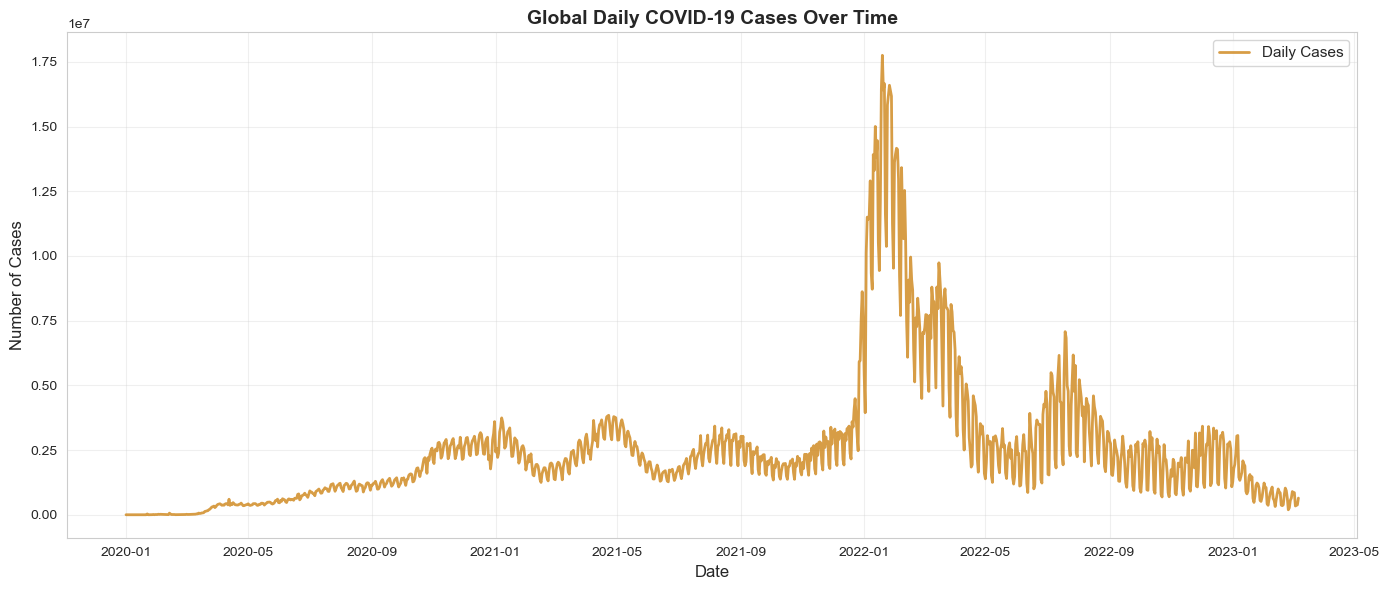

In [20]:
# ======= PART 6: VISUALIZATION =======
# CHART 1: Gloabal Cases & Deaths Over Time

print("-"*50)
print("CHART 1: GLOBAL COVID-19 CASES & DEATHS OVER TIME")
print("-"*50)

daily_global = df.groupby('date').agg({
    'new_cases': 'sum',
    'new_deaths': 'sum'
}).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_global['date'], daily_global['new_cases'], label='Daily Cases',
        linewidth=2, color = "#ce8518c8", alpha=0.8)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Number of Cases', fontsize=12)
ax.set_title('Global Daily COVID-19 Cases Over Time', fontsize=14, fontweight = 'bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart1.png', dpi=300)
print("Chart saved to chart1.png file")
plt.show()

--------------------------------------------------
CHART 2: TOP 10 COUNTRIES BY TOTAL CASES
--------------------------------------------------
Chart saved to chart2.png file


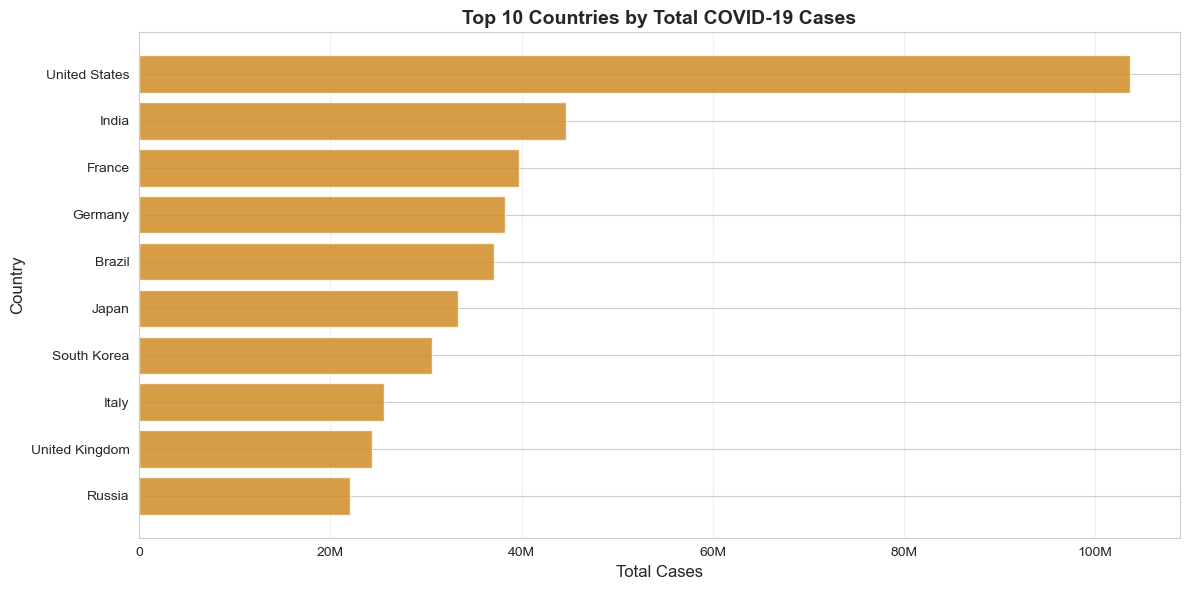

In [21]:
# CHART 2: Top 10 Countries by Cases

print("-"*50)
print("CHART 2: TOP 10 COUNTRIES BY TOTAL CASES")
print("-"*50)

top_10 = df_latest.nlargest(10, 'total_cases').sort_values('total_cases')

plt.figure(figsize=(12, 6))
plt.barh(top_10['location'], top_10['total_cases'],
        color = "#ce8518c8", alpha=0.8)
plt.xlabel('Total Cases', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.title('Top 10 Countries by Total COVID-19 Cases', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3, axis='x')

# format x-axis to show numbers with commas (e.g., 1M instead of 1000000)
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x > 0 else '0'))

plt.tight_layout()
plt.savefig('chart2.png', dpi=300)
print("Chart saved to chart2.png file")
plt.show()


--------------------------------------------------
CHART 3: CASES VS DEATHS BY CONTINENT
--------------------------------------------------
Chart saved to chart3.png file


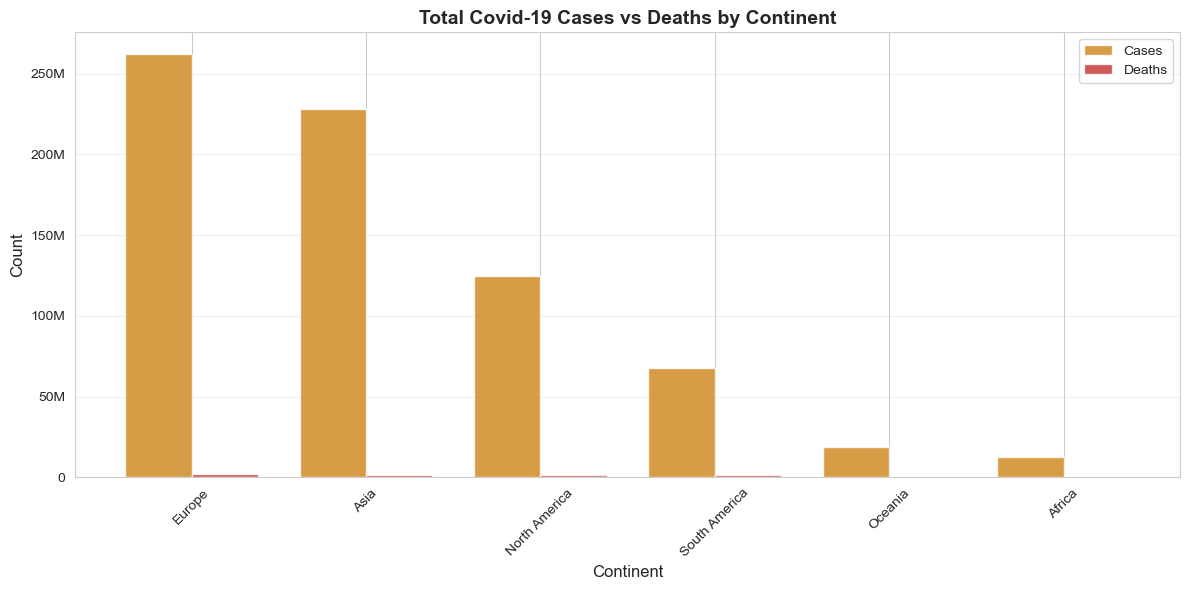

In [22]:
# CHART 3: Cases Vs Deaths by Continent

print("-"*50)
print("CHART 3: CASES VS DEATHS BY CONTINENT")
print("-"*50)

continent_data = df_latest.groupby('continent').agg({
    'total_cases': 'sum',
    'total_deaths': 'sum'
}).reset_index()
continent_data = continent_data.sort_values('total_cases', ascending=False)
#print(continent_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(continent_data['continent']))
width = 0.38

bars_1 = ax.bar(x - width/2, continent_data['total_cases'], width,
                label='Cases', color="#ce8518c8", alpha=0.8)

bars_2 = ax.bar(x + width/2, continent_data['total_deaths'], width,
                label='Deaths', color="#c42e2e8c", alpha=0.8)


ax.set_xlabel('Continent', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Total Covid-19 Cases vs Deaths by Continent', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(continent_data['continent'], rotation = 45, ha = 'center')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

#format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x > 0 else '0'))

plt.tight_layout()
plt.savefig('chart3.png', dpi=300)
print("Chart saved to chart3.png file")
plt.show()

--------------------------------------------------
CHART 4: MULTI-COUNTRY COMPARISON OVER TIME
--------------------------------------------------
Chart saved to chart4.png file


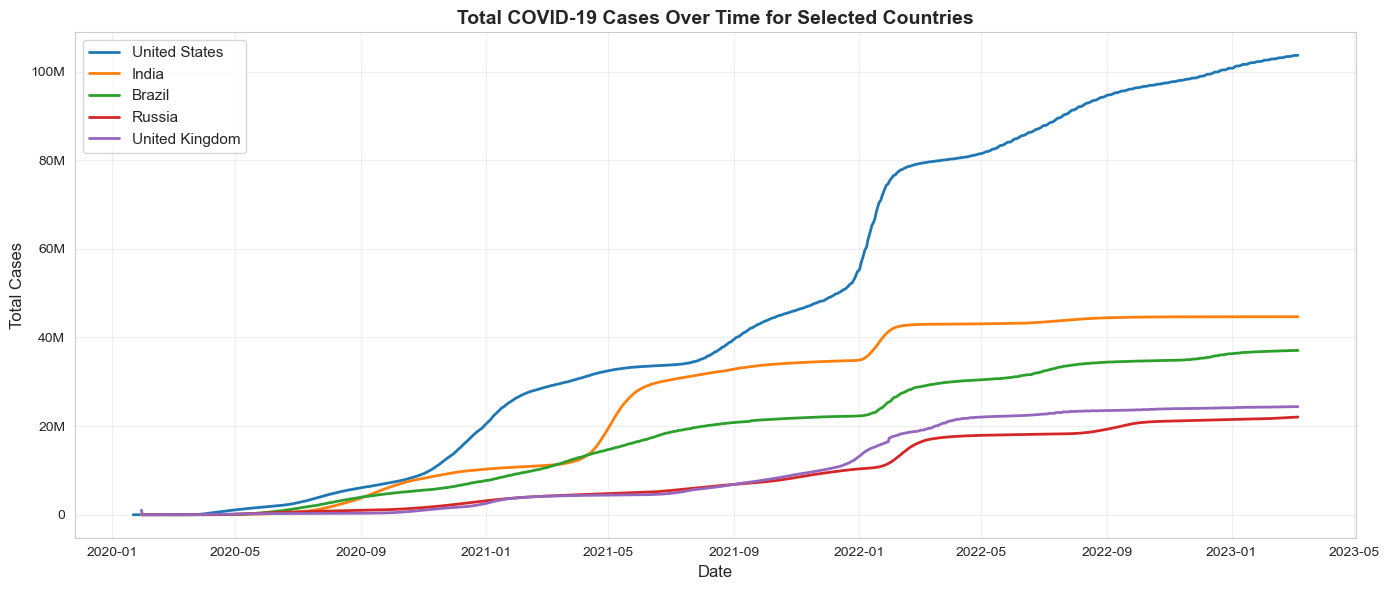

In [23]:
# CHART 4: Multi-Country Comparison Over Time

print("-"*50)
print("CHART 4: MULTI-COUNTRY COMPARISON OVER TIME")
print("-"*50)

countries = ['United States', 'India', 'Brazil', 'Russia', 'United Kingdom']
fig, ax = plt.subplots(figsize=(14, 6))

for country in countries:
    country_data = df[df['location'] == country].sort_values('date')
    if len(country_data) > 0:
        ax.plot(country_data['date'], country_data['total_cases'], 
                label=country, linewidth=2)
        
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Cases', fontsize=12)
ax.set_title('Total COVID-19 Cases Over Time for Selected Countries', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)

#Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e6)}M' if x > 0 else '0'))

plt.tight_layout()
plt.savefig('chart4.png', dpi=300)
print("Chart saved to chart4.png file")
plt.show()

--------------------------------------------------
CHART 5: COVID-19 Metrics by Continent (Box Plots)
--------------------------------------------------
Death rate statistics by continent:
                    min       25%       50%       75%       max
continent                                                      
Africa         0.070855  0.957259  1.538116  2.104297  3.646477
Asia           0.033536  0.256316  0.808359  1.444920  3.770125
Europe         0.125755  0.515502  0.762061  1.675265  4.053173
North America  0.539172  0.817480  1.246035  2.127685  2.514473
South America  0.736438  1.269066  1.776257  2.062279  3.406800

Cases per 100k by Continent:
                       min           25%           50%           75%  \
continent                                                              
Africa           36.279024    275.945799    488.529328   1642.318981   
Asia            178.703678   2895.553038   8550.314437  22451.265487   
Europe          356.825818  17338.616372  327

C:\Users\jayvy\AppData\Local\Temp\ipykernel_23864\4199493060.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(death_rate_by_continent, labels = continents, patch_artist = True, widths=0.6)


Chart saved to chart5.png file


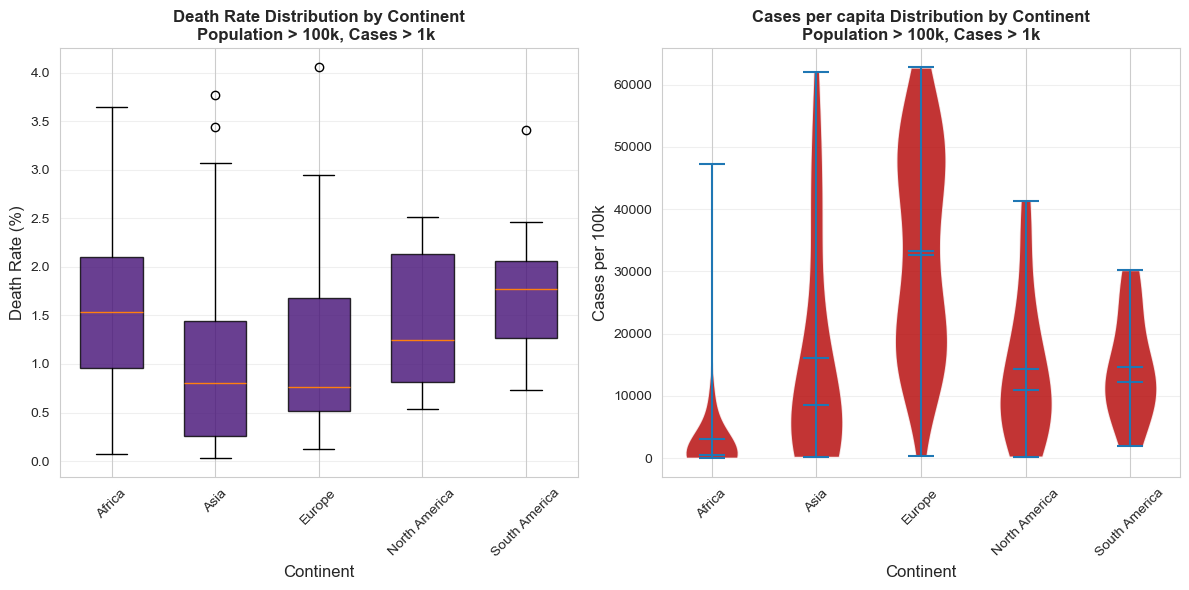

In [24]:
# CHART 5: Box Plot Comparison

print("-"*50)
print("CHART 5: COVID-19 Metrics by Continent (Box Plots)")
print("-"*50)

#filtering population > 100k and cases > 1k 
df_latest = df_latest[(df_latest['population'] > 100000) & (df_latest['total_cases'] > 1000)]


df_latest['death_rate_%'] = (df_latest['total_deaths'] / df_latest['total_cases']) *100
df_latest['cases_per_100k'] = (df_latest['total_cases'] / df_latest['population']) * 100000

#removing oceania as continent
df_latest = df_latest[df_latest['continent'] != 'Oceania']

#remove possible extreme outliers using IQR method
def remove_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    return data[(data[column] > Q1 -1.5*IQR) & (data[column] < Q3 + 1.5*IQR)]

df_latest = remove_outliers(df_latest, 'death_rate_%')
df_latest = remove_outliers(df_latest, 'cases_per_100k')

#summarize statistics by continent
print("Death rate statistics by continent:")
print(df_latest.groupby('continent')['death_rate_%'].describe()[['min', '25%', '50%', '75%', 'max']])

print("\nCases per 100k by Continent:")
print(df_latest.groupby('continent')['cases_per_100k'].describe()[['min', '25%', '50%', '75%', 'max']])

#create side by side box plots for death rates and cases per 100k by continent
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

#prepare data by continent
continents = sorted(df_latest['continent'].dropna().unique())
death_rate_by_continent = [df_latest[df_latest['continent'] == cont]['death_rate_%'].values
                           for cont in continents]
cases_per_100k_by_continent = [df_latest[df_latest['continent'] == cont]['cases_per_100k'].values
                               for cont in continents]

#box plot 1: Death rates by continent
bp = axes[0].boxplot(death_rate_by_continent, labels = continents, patch_artist = True, widths=0.6)
for patch in bp['boxes']:
    patch.set_facecolor("#440F76")
    patch.set_alpha(0.8)

axes[0].set_title('Death Rate Distribution by Continent\nPopulation > 100k, Cases > 1k ',
                 fontsize=12, fontweight='bold')
axes[0].set_ylabel('Death Rate (%)', fontsize=12)
axes[0].set_xlabel('Continent', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)


#box plot 2: Cases per 100k by continent
vp = axes[1].violinplot(cases_per_100k_by_continent, showmeans = True, showmedians = True)

for body in vp['bodies']:
    body.set_facecolor("#b30101")
    body.set_alpha(0.8)

axes[1].set_xticks(range(1, len(continents)+1))
axes[1].set_xticklabels(continents, rotation=45)
axes[1].set_title('Cases per capita Distribution by Continent\nPopulation > 100k, Cases > 1k',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Cases per 100k', fontsize=12)
axes[1].set_xlabel('Continent', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('chart5.png', dpi=300)
print("Chart saved to chart5.png file")
plt.show()

--------------------------------------------------
CHART 6: Heatmap of Correlations
--------------------------------------------------
Chart saved to chart6.png file


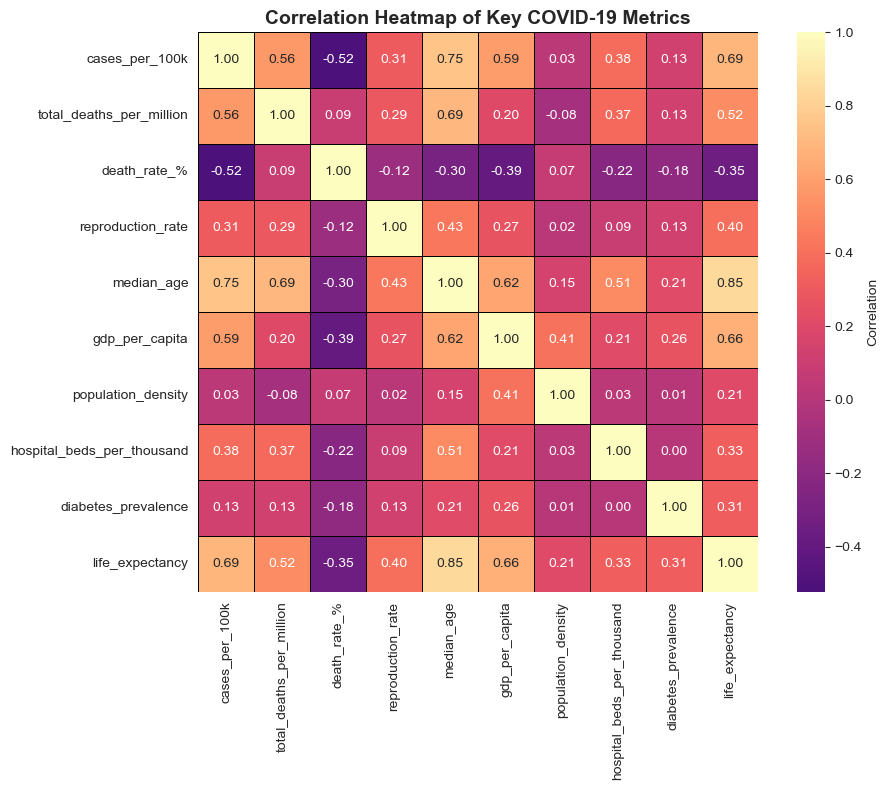

In [25]:
# CHART 6: Heatmap of Correlations

print("-"*50)
print("CHART 6: Heatmap of Correlations")
print("-"*50)

#get relevant numeric columns for correlation analysis
top_col = [
    'cases_per_100k',
    'total_deaths_per_million',
    'death_rate_%',
    'reproduction_rate',
    'median_age',
    'gdp_per_capita',
    'population_density',
    'hospital_beds_per_thousand',
    'diabetes_prevalence',
    'life_expectancy'
]

#select numeric columns for correlation
correlation_matrix = df_latest[top_col].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, cmap= 'magma', center = 0, annot=True, fmt=".2f", 
            square = True, cbar_kws = { 'label': 'Correlation'}, linewidths=0.5, linecolor='black')
plt.title('Correlation Heatmap of Key COVID-19 Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart6.png', dpi=300)
print("Chart saved to chart6.png file")
plt.show()

--------------------------------------------------
CHART 7: Human Development Index (HDI) vs Death Rate
--------------------------------------------------
Chart saved to chart7.png file


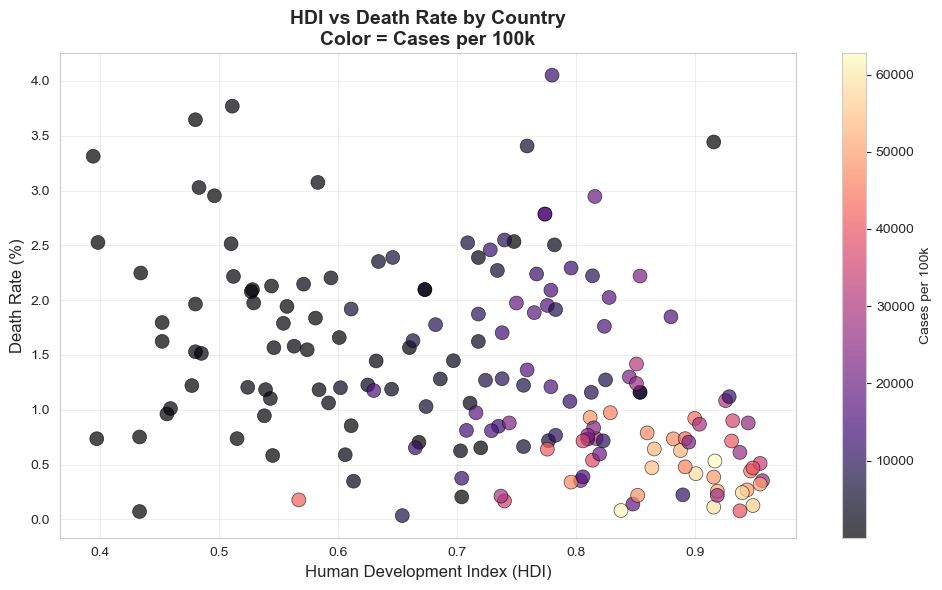

In [26]:
# CHART 7: HDI vs Death Rate (Scatter Plot)

print("-"*50)
print("CHART 7: Human Development Index (HDI) vs Death Rate")
print("-"*50)

#drop rows with missing HDI or death rate
df_scatter = df_latest.dropna(subset=['human_development_index', 'death_rate_%'])

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_scatter['human_development_index'], df_scatter['death_rate_%'],
                      s = 100, alpha=0.7, c = df_scatter['cases_per_100k'], 
                      cmap='magma', edgecolor='black', linewidth=0.5)
plt.xlabel('Human Development Index (HDI)', fontsize=12)
plt.ylabel('Death Rate (%)', fontsize=12)
plt.title('HDI vs Death Rate by Country\nColor = Cases per 100k', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, label = 'Cases per 100k')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('chart7.png', dpi=300)
print("Chart saved to chart7.png file")
plt.show()


--------------------------------------------------
CHART 8: COVID-19 New Deaths Trend by Continent
--------------------------------------------------
continent    Africa      Asia    Europe  North America  South America
year_month                                                           
2020-01         0.0     767.0     385.0            0.0            0.0
2020-02         2.0    5767.0    2169.0            1.0            0.0
2020-03      4003.0    9818.0   47924.0        25205.0         1879.0
2020-04      3239.0   40201.0  125721.0        81298.0        12057.0
2020-05      4139.0   24349.0   55362.0        66111.0        43811.0
2020-06      6044.0   37966.0   27229.0        51983.0        57449.0
2020-07      9670.0   51964.0   23226.0        61756.0        66046.0
2020-08     10256.0   58647.0   22508.0        62263.0        66502.0
2020-09      6203.0   64224.0   27143.0        51148.0        51784.0
2020-10      7117.0   60434.0   57219.0        51461.0        43953.0
2020-11   

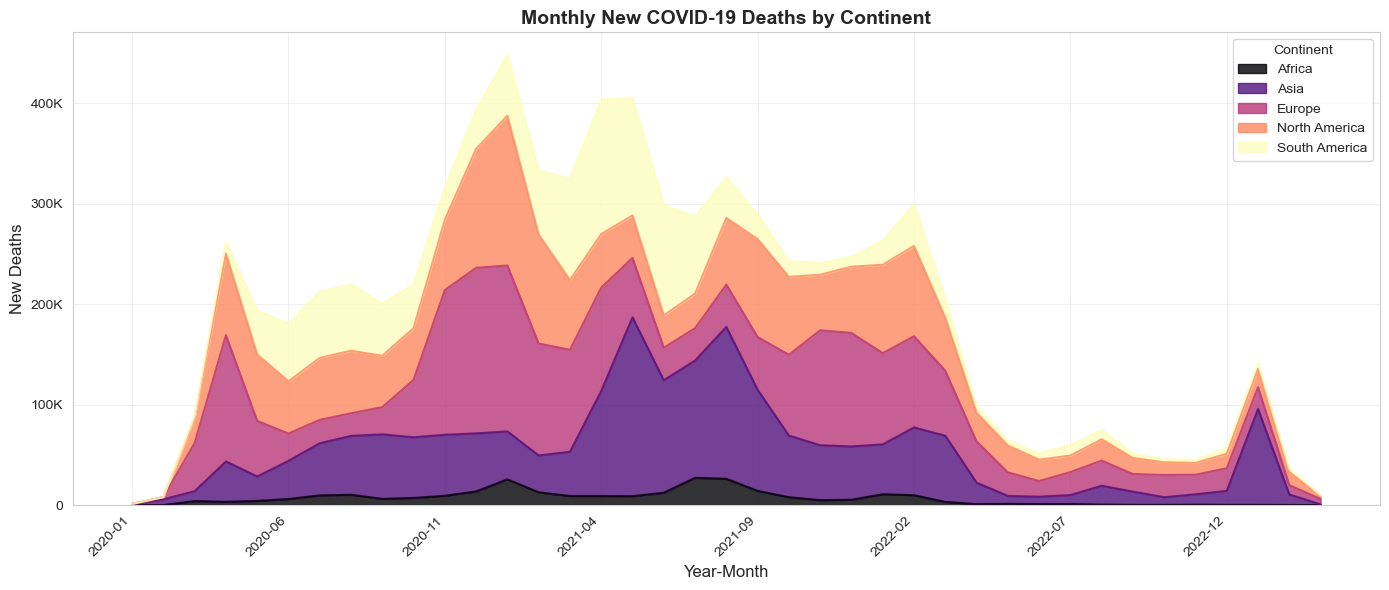

In [27]:
# CHART 8: COVID-19 Deaths Stacked Area Chart

print("-"*50)
print("CHART 8: COVID-19 New Deaths Trend by Continent")
print("-"*50)

df_area = df.copy()
df_area = df_area[df_area['continent'] != 'Oceania']
df_area['year_month'] = df_area['date'].dt.to_period('M')

area_data = df_area.groupby(['year_month', 'continent'])['new_deaths'].sum().unstack(fill_value=0)
area_data.index = area_data.index.astype(str)

print(area_data)
print('\nShape:', area_data.shape)
print('Total Death per continent:\n', area_data.sum())
area_data.plot(kind = 'area', figsize=(14, 6), cmap='magma', alpha=0.8)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('New Deaths', fontsize=12)
plt.title('Monthly New COVID-19 Deaths by Continent', fontsize=14, fontweight='bold')
plt.legend(title='Continent', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha= 'right')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1e3)}K' if x > 0 else '0'))

plt.tight_layout()
plt.savefig('chart8.png', dpi=300)
print("Chart saved to chart8.png file")
plt.show()

## 💡 Key Findings & Insights

An overview of major statistics from the analysis.

In [28]:
# ---- PART7: KEY INSTIGHTS ----

print("-"*50)
print("KEY FINDINGS & INSIGHTS")
print("-"*50)

print('\n1. GLOBAL IMPACT:')
total_cases = df_latest['total_cases'].sum()
total_deaths = df_latest['total_deaths'].sum()
global_death_rate = (total_deaths / total_cases) * 100 if total_cases > 0 else 0

print(f" - Total Global Cases: {total_cases:,.0f}")
print(f" - Total Global Deaths: {total_deaths:,.0f}")
print(f" - Global Death Rate: {global_death_rate:.2f}%")
print(f" - Countries Affected: {df_latest['location'].nunique()}")

most_affected = df_latest.nlargest(1, 'total_cases').iloc[0]
print(f" - Most Affected Country: {most_affected['location']} with {most_affected['total_cases']:,.0f} cases")


print('\n2. TOP 3 AFFECTED COUNTRIES (by cases):')
top3 = df_latest.nlargest(3, 'total_cases')[['location', 'total_cases', 'total_deaths']]
for index, row in top3.iterrows():
    print(f" - {row['location']}: [{row['total_cases']:,.0f} CASES] [{row['total_deaths']:,.0f} DEATHS]")

print('\n3. CONTINENTAL DISTRIBUTION:')
continent_top = continent_stats.nlargest(1, 'total_cases').iloc[0]
print(f" - Most Affected: {continent_top['continent']} by ({continent_top['total_cases']:,.0f} CASES)")
print(f" - Highest Death Rate: {continent_stats.nlargest(1, 'death_rate_%').iloc[0]['continent']} by " 
      f"({continent_stats.nlargest(1, 'death_rate_%').iloc[0]['death_rate_%']:.2f}%)")

print('\n4. TEMPORAL TRENDS:')
peak_month_idx = monthly_stats['new_cases'].idxmax()
peak_month = monthly_stats.loc[peak_month_idx]
print(f" - Peak Cases Month: {peak_month['year_month']} with {peak_month['new_cases']:,.0f} new cases")
print(f" - Data Range from {df['date'].min().date()} to {df['date'].max().date()}")

print('\n5. DEATH RATES ANALYSIS:')
highest_death_rate = df_latest.nlargest(1, 'death_rate_%').iloc[0]
print(f" - Highest Death Rate: {highest_death_rate['location']} by {highest_death_rate['death_rate_%']:.2f}%")
print(f" - Average Death Rate: {df_latest['death_rate_%'].mean():.2f}%")

print('\n6. QUICK SUMMARY TABLE:')
summary = pd.DataFrame({
    'Metric': ['Total Cases', 'Total Deaths', 'Death Rate', 'Countries', 'Peak Month'],
    'Value': [
        f"{total_cases:,.0f}",
        f"{total_deaths:,.0f}",
        f"{global_death_rate:.2f}%",
        f"{df_latest['location'].nunique()}",
        f"{peak_month['year_month']}"
    ]
})
print(summary.to_string(index=False))


--------------------------------------------------
KEY FINDINGS & INSIGHTS
--------------------------------------------------

1. GLOBAL IMPACT:
 - Total Global Cases: 641,811,113
 - Total Global Deaths: 6,175,501
 - Global Death Rate: 0.96%
 - Countries Affected: 170
 - Most Affected Country: United States with 103,680,242 cases

2. TOP 3 AFFECTED COUNTRIES (by cases):
 - United States: [103,680,242 CASES] [1,122,599 DEATHS]
 - India: [44,689,919 CASES] [530,775 DEATHS]
 - France: [39,689,456 CASES] [165,166 DEATHS]

3. CONTINENTAL DISTRIBUTION:
 - Most Affected: Europe by (262,454,917 CASES)
 - Highest Death Rate: Africa by (2.07%)

4. TEMPORAL TRENDS:
 - Peak Cases Month: 2022-01 with 392,281,641 new cases
 - Data Range from 2020-01-01 to 2023-03-07

5. DEATH RATES ANALYSIS:
 - Highest Death Rate: Bosnia and Herzegovina by 4.05%
 - Average Death Rate: 1.31%

6. QUICK SUMMARY TABLE:
      Metric       Value
 Total Cases 641,811,113
Total Deaths   6,175,501
  Death Rate       0.96%
  